# 00 — Playground (data/raw)

Objetivo:
- Cargar los JSON crudos en `data/raw`.
- Hacer un vistazo rápido (head, tipos, missingness).
- Explorar `price_histories` por mercado.

In [16]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

raw_dir = Path("../data/raw")
raw_dir

PosixPath('../data/raw')

## 1. Cargar datos

In [17]:
with open(raw_dir / "active_markets.json") as f:
    active = json.load(f)

with open(raw_dir / "resolved_markets.json") as f:
    resolved = json.load(f)

with open(raw_dir / "price_histories.json") as f:
    price_histories = json.load(f)

active_df = pd.DataFrame(active)
resolved_df = pd.DataFrame(resolved)

len(active_df), len(resolved_df), len(price_histories)

(900, 24000, 24900)

## 2. Vista rápida de los mercados

In [18]:
active_df.head(3)

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,description,outcomes,outcomePrices,volume,active,closed,marketMakerAddress,createdAt,updatedAt,new,...,deployingTimestamp,rfqEnabled,holdingRewardsEnabled,feesEnabled,requiresTranslation,feeType,gameStartTime,secondsDelay,makerBaseFee,takerBaseFee,clobRewards,oneHourPriceChange,sportsMarketType,feeSchedule,oneMonthPriceChange,negRiskMarketID,line,eventStartTime,gameId,makerRebatesFeeShareBps
0,1640919,US forces enter Iran by April 30?,0x6d0e09d0f04572d9b1adad84703458b0297bc5603b69...,us-forces-enter-iran-by-april-30-899,,2026-04-30T00:00:00Z,4877152.72031,2026-03-18T16:32:52.336057Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,This market will resolve to “Yes” if active US...,"[Yes, No]","[0.9975, 0.0025]",73471351.80278176,True,False,,2026-03-18T16:29:07.71272Z,2026-04-06T05:03:01.377619Z,False,...,2026-03-18T16:30:33.401912Z,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1791549,Rockets vs. Warriors,0x73ade848497f1f1f77c75e7f2385839c85a4839de53d...,nba-hou-gsw-2026-04-05,https://www.nba.com/,2026-04-06T02:00:00Z,598491.88814,2026-03-30T14:03:07.23531Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,"In the upcoming NBA game, scheduled for April ...","[Rockets, Warriors]","[0.9995, 0.0005]",4393502.086994968,True,False,,2026-03-30T14:00:17.235149Z,2026-04-06T05:04:00.190696Z,False,...,2026-03-30T14:00:27.887017Z,False,False,True,False,sports_fees_v2,2026-04-06 02:00:00+00,3.0,1000.0,1000.0,"[{'id': '131249', 'conditionId': '0x73ade84849...",0.1945,moneyline,"{'exponent': 1, 'rate': 0.03, 'takerOnly': Tru...",NaN,NaN,NaN,NaN,NaN,NaN
2,1455604,Will Trump talk to Xi Jinping in March?,0x6aa39e488afd5dd8e1cd995258c28c3c485dbc4d467d...,will-trump-talk-to-xi-jinping-in-march-165,,2026-03-31T00:00:00Z,4692160.05501,2026-03-01T18:50:47.83724Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,"This market will resolve to ""Yes"" if the liste...","[Yes, No]","[0.0005, 0.9995]",9988157.739661004,True,False,,2026-02-27T17:41:49.939719Z,2026-04-06T05:03:44.083209Z,False,...,2026-03-01T18:48:06.169085Z,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.7095,NaN,NaN,NaN,NaN,NaN


In [19]:
resolved_df.head(3)

,id,question,conditionId,slug,endDate,startDate,image,icon,description,outcomes,outcomePrices,active,closed,marketMakerAddress,createdAt,updatedAt,closedTime,new,featured,submitted_by,...,volume24hr,volume1wk,volume1mo,volume1yr,volume24hrClob,volume1wkClob,volume1moClob,volume1yrClob,eventStartTime,secondsDelay,sportsMarketType,line,volume24hrAmm,volume1wkAmm,volume1moAmm,volume1yrAmm,volumeAmm,oneYearPriceChange,gameId,makerRebatesFeeShareBps
0,1560199,Unitas Labs FDV above $20M one day after launch?,0x3b8ab881e59dd64caad009d5c098751a5d627254ec68...,unitas-labs-fdv-above-20m-one-day-after-launch,2028-01-01T05:00:00Z,2026-03-11T17:47:48.830665Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,"This market will resolve to ""Yes"" if the Fully...","[Yes, No]","[1, 0]",True,True,,2026-03-11T17:44:56.617594Z,2026-03-15T18:43:16.346265Z,2026-03-15 01:20:57+00,False,False,0x91430CaD2d3975766499717fA0D66A78D814E5c5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1541276,Nebula3 FDV above $100M one day after launch?,0xfe365f1129ff1193f8f2a06397b2a0eeffe1bb38c32a...,nebula3-fdv-above-100m-one-day-after-launch,2028-01-01T05:00:00Z,2026-03-09T18:41:48.524705Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,"This market will resolve to ""Yes"" if the Fully...","[Yes, No]","[0, 1]",True,True,,2026-03-09T18:38:55.077467Z,2026-03-13T20:07:36.055531Z,2026-03-12 22:30:25+00,False,False,0x91430CaD2d3975766499717fA0D66A78D814E5c5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1744638,P2P FDV above $80M one day after launch?,0x89f5b1d75883a1cceb46fff067a2bfa21317f7be4b7a...,p2p-fdv-above-80m-one-day-after-launch-919-564...,2028-01-01T05:00:00Z,2026-03-27T17:30:46.015Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,"This market will resolve to ""Yes"" if the Fully...","[Yes, No]","[0, 1]",True,True,,2026-03-27T17:27:47.170083Z,2026-04-03T16:04:39.254361Z,2026-04-03 04:42:15+00,False,False,0x91430CaD2d3975766499717fA0D66A78D814E5c5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Campos clave, tipos y missingness

In [20]:
key_fields = [
    "id", "question", "slug", "outcomes", "outcomePrices", "clobTokenIds",
    "volume", "volume24hr", "liquidity", "bestBid", "bestAsk", "spread",
    "active", "closed", "resolution", "resolutionSource", "endDate",
    "startDate", "createdAt", "updatedAt", "closedTime", "negRisk",
]

def summarize(df):
    rows = []
    for f in key_fields:
        if f in df.columns:
            series = df[f]
            example = series.dropna().iloc[0] if series.notna().any() else None
            rows.append({
                "field": f,
                "dtype": series.dtype,
                "nonnull": int(series.notna().sum()),
                "example": str(example)[:80],
            })
        else:
            rows.append({"field": f, "dtype": None, "nonnull": 0, "example": None})
    return pd.DataFrame(rows)

summarize(active_df)

,field,dtype,nonnull,example
0,id,str,900,1640919
1,question,str,900,US forces enter Iran by April 30?
2,slug,str,900,us-forces-enter-iran-by-april-30-899
3,outcomes,object,900,"['Yes', 'No']"
4,outcomePrices,object,900,"['0.9975', '0.0025']"
5,clobTokenIds,object,900,['29161841202062237498398496448777074703549460...
6,volume,str,900,73471351.80278176
7,volume24hr,float64,900,35365651.48836588
8,liquidity,str,900,4877152.72031
9,bestBid,float64,791,0.997


In [21]:
summarize(resolved_df)

,field,dtype,nonnull,example
0,id,str,24000,1560199
1,question,str,24000,Unitas Labs FDV above $20M one day after launch?
2,slug,str,24000,unitas-labs-fdv-above-20m-one-day-after-launch
3,outcomes,object,24000,"['Yes', 'No']"
4,outcomePrices,object,24000,"['1', '0']"
5,clobTokenIds,object,24000,['26857257880535603845078121646552020575226132...
6,volume,str,21972,2702.955438
7,volume24hr,float64,7045,99.99
8,liquidity,str,3686,0
9,bestBid,float64,11873,0.999


## 4. Price histories (dict por market_id)

In [22]:
lengths = pd.Series({mid: len(hist) for mid, hist in price_histories.items()})
lengths.describe()

count    24900.000000
mean        97.621044
std        162.225691
min          1.000000
25%          8.000000
50%         21.000000
75%        109.000000
max        738.000000
dtype: float64

In [23]:
import random

sample_market_id = random.choice(list(price_histories.keys()))
print("sample_market_id:", sample_market_id)

hist_df = pd.DataFrame(price_histories[sample_market_id])

if not hist_df.empty:
    hist_df["timestamp"] = pd.to_datetime(hist_df["t"], unit="s", utc=True)
    hist_df.head(5)
else:
    hist_df

sample_market_id: 1814428


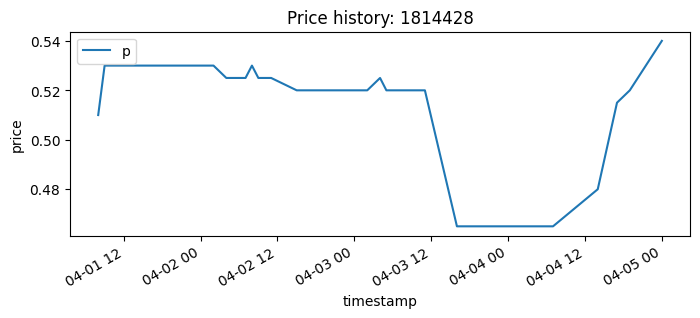

In [24]:
if not hist_df.empty:
    ax = hist_df.plot(x="timestamp", y="p", figsize=(8, 3), title=f"Price history: {sample_market_id}")
    ax.set_xlabel("timestamp")
    ax.set_ylabel("price")
    plt.show()

## 5. Lookup rápido por market_id

In [25]:
market_id = sample_market_id  # cambia esto por un ID que te interese

row = active_df.loc[active_df["id"] == market_id]
if not row.empty:
    display(row.iloc[0])
else:
    row = resolved_df.loc[resolved_df["id"] == market_id]
    display(row.iloc[0]) if not row.empty else f"No encontrado: {market_id}"

id                                                                   1814428
question                      MLP Academics Heidelberg vs. Rostock Seawolves
conditionId                0x295b081b48f867e90fdb15dc73d31d2efdf3a4cda120...
slug                                                bkbbl-mlp-ros-2026-04-05
endDate                                                 2026-04-12T13:00:00Z
                                                 ...                        
volume1yrAmm                                                             NaN
volumeAmm                                                                NaN
oneYearPriceChange                                                       NaN
gameId                                                                   NaN
makerRebatesFeeShareBps                                                  NaN
Name: 1569, Length: 110, dtype: object